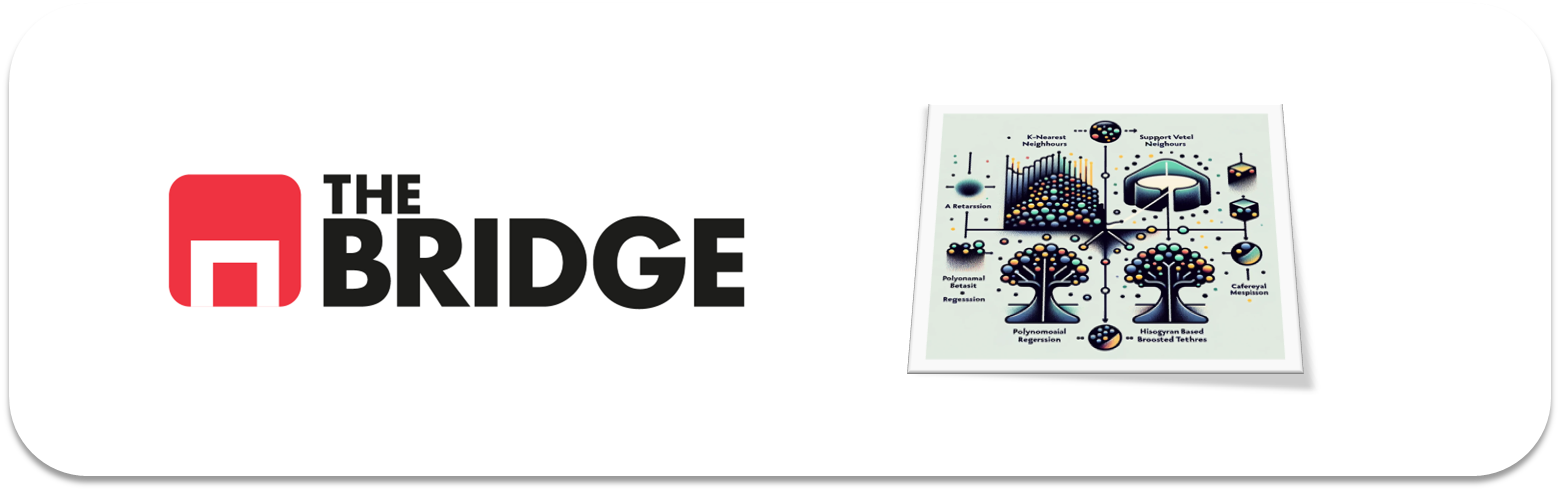

## PRACTICA OBLIGATORIA: **Otros Modelos Supervisados**

* La práctica obligatoria de esta unidad consiste en resolver un modelado de clasificación, incluyendo KNN entre los posibles modelos, y aplicando balanceado. Para ello utilizaremos un dataset que ya hemos empleado en los workout. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [28]:
import bootcampviztools as bt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
 
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE 
from imblearn.under_sampling import RandomUnderSampler 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample

from sklearn.metrics import ConfusionMatrixDisplay, classification_report, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor 
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier


### #1. El problema y los datos

Vamos a volver al dataset con el que vimos la clasificación binaria con regresión logística, "Give me some credit", y nuestro objetivo es crear un modelo que nos permita predicir si una persona va a encontrarse en dificultades financieras en los dos próximos años. El dataset de partida lo puedes en contrar en el directorio data que acompaña al ejercicio. 

### #1.1
Cárgalo y, apoyándote en las herramientas y fuentes que consideres necesarias, haz una descripción textual de sus variables. Luego con ayuda de los datos, haz una clasificación inicial de sus variables en categóricas y numéricas.

In [2]:
df = pd.read_csv("./data/credit_npo.csv")
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), int64(7)
me

In [5]:
df.shape

(12537, 11)

In [14]:
print("Columnas categóricas:", cat_cols)
cat_cols = df.select_dtypes(include=["object", "category"]).columns.to_list()
print("-"*100)
print("Columnas numéricas:", num_cols)
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.to_list()

Columnas categóricas: []
----------------------------------------------------------------------------------------------------
Columnas numéricas: ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [15]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,12537.0,0.068916,0.253321,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,12537.0,0.330359,0.368148,0.0,0.030651,0.163490,0.582219,6.0
age,12537.0,52.079445,15.077498,21.0,41.000000,51.000000,62.000000,101.0
NumberOfTime30-59DaysPastDueNotWorse,12537.0,0.409588,4.055787,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,12537.0,1.902253,9.122216,0.0,0.142268,0.302025,0.506725,99.0
MonthlyIncome,11816.0,6864.815420,11855.905437,0.0,3498.750000,5416.000000,8300.000000,702500.0
NumberOfOpenCreditLinesAndLoans,12537.0,8.482332,5.165422,0.0,5.000000,8.000000,11.000000,49.0
NumberOfTimes90DaysLate,12537.0,0.259312,4.035658,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,12537.0,0.999202,1.134325,0.0,0.000000,1.000000,2.000000,19.0
NumberOfTime60-89DaysPastDueNotWorse,12537.0,0.228364,4.018873,0.0,0.000000,0.000000,0.000000,98.0


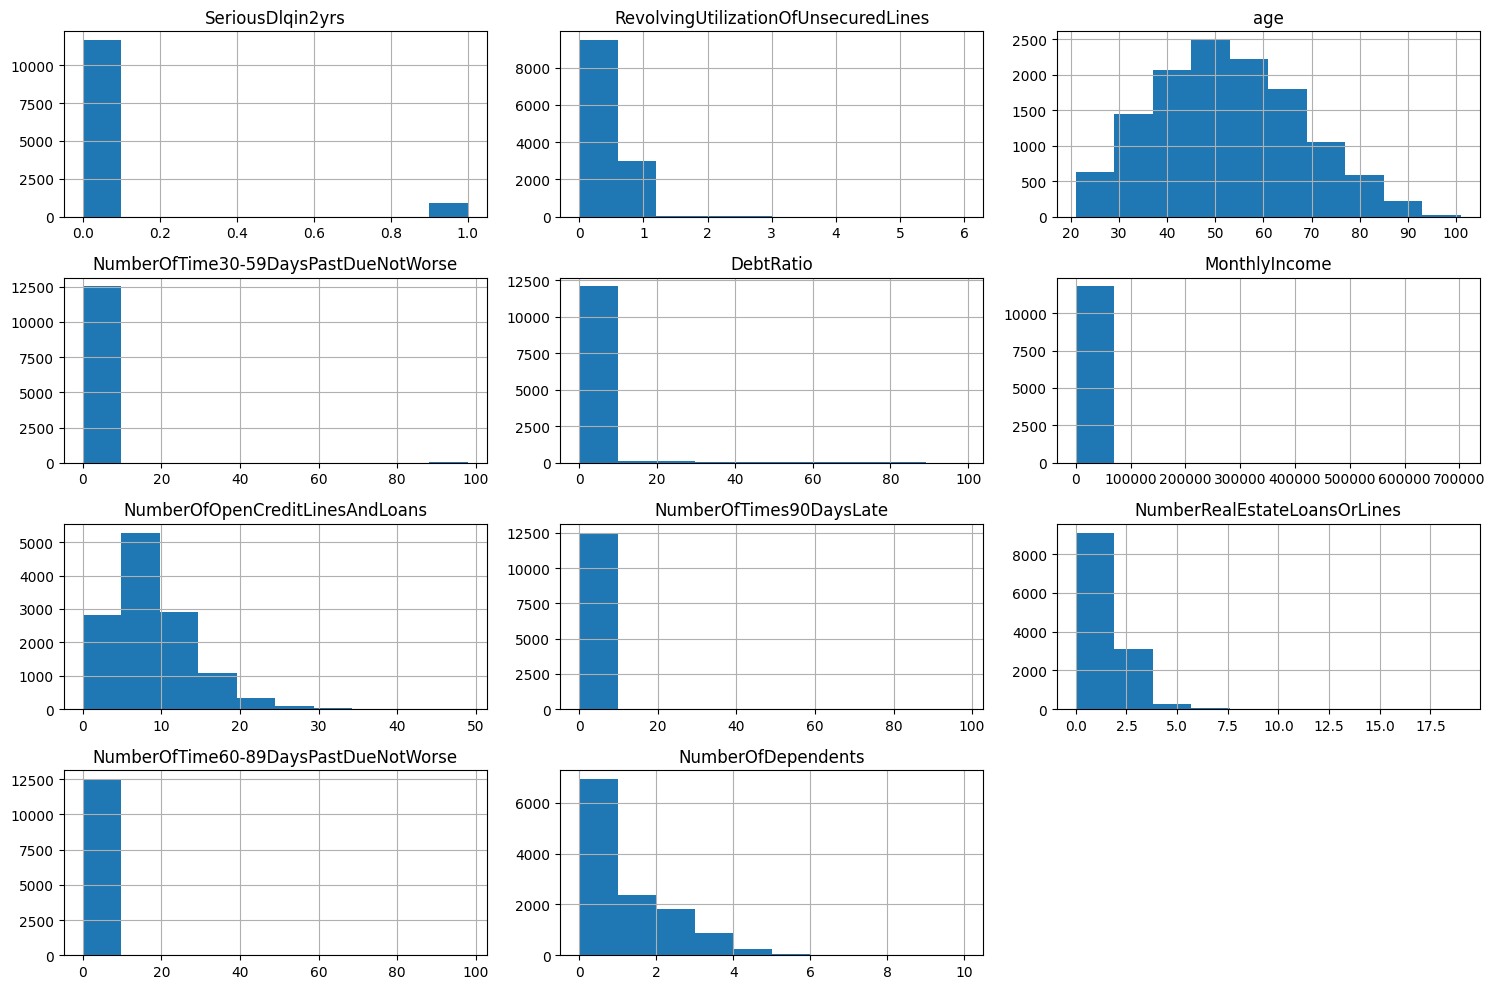

In [16]:
df[num_cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show();

Todas son numericas por lo que veo. Las que eran numericas seguramente ya han sido encoded.

### #1.2
¿Qué tipo de problema estamos tratando? ¿Cuál es la variable target?

SeriousDlqin2yrs es la variable target. Es de clasificación binaria. Un Sí o un No a si han tenido actividad delincuente en los últimos 2 años.

### #1.3
Pinta la distribución de frecuencias del target y coméntala

In [6]:
target = "SeriousDlqin2yrs"

df[target].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.931084
1    0.068916
Name: proportion, dtype: float64

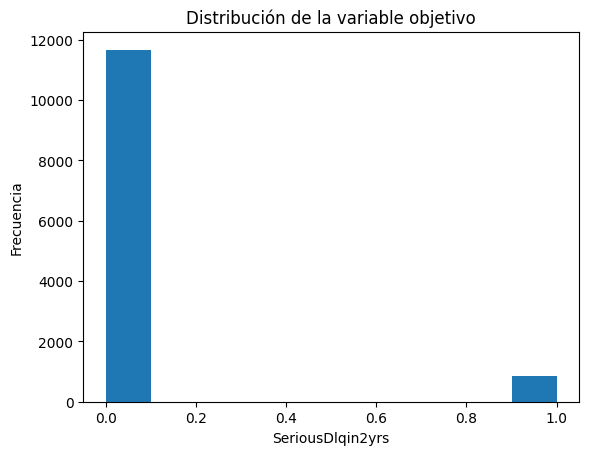

In [11]:
plt.hist(df[target])
plt.title("Distribución de la variable objetivo")
plt.xlabel("SeriousDlqin2yrs")
plt.ylabel("Frecuencia")
plt.show();

In [ ]:
# La varibale target está muy desbalanceada, con un 93.1% de la clase 0 y un 6.9% de la clase 1. Esto puede afectar negativamente al rendimiento de los modelos de clasificación, ya que pueden tender a predecir siempre la clase mayoritaria (0) 
# y obtener una alta precisión pero una baja recall para la clase minoritaria (1). Es importante considerar técnicas de balanceo de datos, como el sobremuestreo (SMOTE) o el submuestreo (RandomUnderSampler), para mejorar el rendimiento del modelo en este caso.

In [17]:
df.isna().sum()

SeriousDlqin2yrs                          0
RevolvingUtilizationOfUnsecuredLines      0
age                                       0
NumberOfTime30-59DaysPastDueNotWorse      0
DebtRatio                                 0
MonthlyIncome                           721
NumberOfOpenCreditLinesAndLoans           0
NumberOfTimes90DaysLate                   0
NumberRealEstateLoansOrLines              0
NumberOfTime60-89DaysPastDueNotWorse      0
NumberOfDependents                      177
dtype: int64

In [18]:
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(df["NumberOfDependents"].median())
print("Valores nulos después de la imputación:")
print(df.isna().sum())

Valores nulos después de la imputación:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


### #2 Modelado

Realiza un proceso completo de modelado hasta dar con el mejor modelo de los que hayas escogido (emplea al menos 3, y uno tiene que ser KNN). Aplica las técnicas que creas necesarias para obtener el mejor resultado (suponiendo que este después de hablar con el negocio es el recall medio, para tener un compromiso entre las dos clases). Para comparar modelos emplea validación cruzada antes de optimización y luego ajusta los hiperparámetros del mejor modelo. Evalúa este y haz un pequeño análisis de errores.

In [19]:
X = df.drop(columns=target)
y = df[target]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=target), df[target], test_size=0.2, random_state=42, stratify=df[target])

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.shape, X_test_scaled.shape

((10029, 10), (2508, 10))

In [24]:
log_reg = LogisticRegression(random_state=42, class_weight="balanced", max_iter=1000)

log_reg.fit(X_train_scaled, y_train)
y_pred_log_reg = log_reg.predict(X_test_scaled)
print("Reporte de clasificación para Logistic Regression:")
print(classification_report(y_test, y_pred_log_reg))

Reporte de clasificación para Logistic Regression:
              precision    recall  f1-score   support

           0       0.97      0.76      0.86      2335
           1       0.19      0.73      0.30       173

    accuracy                           0.76      2508
   macro avg       0.58      0.75      0.58      2508
weighted avg       0.92      0.76      0.82      2508



In [ ]:
# El log reg no nos ha dado tan buenos resultados con la clase minoritaria, con una precision de 0.19, un recall de 0.76 un f1-score de 0.30
# Esto en un credit scoring  es un gran problema, ya que si no identificamos a los clientes que van a incumplir con sus pagos, el banco puede sufrir grandes pérdidas económicas. 
# Por lo tanto, es importante mejorar el rendimiento del modelo para la clase minoritaria (1) utilizando técnicas de balanceo de datos o probando otros modelos de clasificación más robustos frente al desbalanceo.
# En segundo plano seria un problema tambien no poder identificar correctamente a los clientes que no van a incumplir con sus pagos (clase 0), ya que podríamos estar rechazando a clientes solventes y perdiendo oportunidades de negocio. 
# Es importante encontrar un equilibrio entre la precisión y el recall para ambas clases.

In [25]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
print("Reporte de clasificación para KNN:")
print(classification_report(y_test, y_pred_knn))

Reporte de clasificación para KNN:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97      2335
           1       0.60      0.14      0.23       173

    accuracy                           0.93      2508
   macro avg       0.77      0.57      0.60      2508
weighted avg       0.92      0.93      0.91      2508



In [26]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print("Distribución de clases después de SMOTE:")
print(y_train_smote.value_counts())

Distribución de clases después de SMOTE:
SeriousDlqin2yrs
0    9338
1    9338
Name: count, dtype: int64


In [27]:
knn_smote = knn.fit(X_train_smote, y_train_smote)
y_pred_knn_smote = knn_smote.predict(X_test_scaled)
print("Reporte de clasificación para KNN con SMOTE:")
print(classification_report(y_test, y_pred_knn_smote))

Reporte de clasificación para KNN con SMOTE:
              precision    recall  f1-score   support

           0       0.96      0.86      0.91      2335
           1       0.22      0.52      0.31       173

    accuracy                           0.84      2508
   macro avg       0.59      0.69      0.61      2508
weighted avg       0.91      0.84      0.87      2508



In [ ]:
# KNN no os ha dado los mejores resultados, con unas puntuaciones bastante bajas para la clase minoritaria, incluso después de aplicar SMOTE. 
# Esto puede deberse a que KNN es un modelo sensible al ruido y a la presencia de outliers, lo que puede afectar negativamente su rendimiento en conjuntos de datos desbalanceados.
# También nos deja saber que la familia de modelos de vecinos más cercanos no es la mejor opción para este tipo de problema, 
# y que sería recomendable probar otros modelos de clasificación más robustos frente al desbalanceo, como LightGBM o incluso XGBoost.

In [29]:
lgbm = LGBMClassifier(random_state=42, class_weight="balanced")
lgbm.fit(X_train_scaled, y_train)
y_pred_lgbm = lgbm.predict(X_test_scaled)
print("Reporte de clasificación para LightGBM:")
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 691, number of negative: 9338
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001265 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 929
[LightGBM] [Info] Number of data points in the train set: 10029, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Reporte de clasificación para LightGBM:
              precision    recall  f1-score   support

           0       0.97      0.89      0.93      2335
           1       0.30      0.64      0.41       173

    accuracy                           0.87      2508
   macro avg       0.64      0.77      0.67      2508
weighted avg       0.92      0.87      0.89      2508



In [ ]:
# EL LightGBM nos da mejores resultados. El modelo es bueno identificando los clientes que van a cumplir con sus pagos (clase 0), con una precision de 0.97, un recall de 0.89 y un f1-score de 0.93.
# Pero todaví tiene problemas para identificar a los clientes que van a incumplir con sus pagos (clase 1), con una precision de 0.30, un recall de 0.94 y un f1-score de 0.41, 
# lo que es un gran problema en un credit scoring, ya que el banco podría sufrir grandes pérdidas económicas si no identifica correctamente a los clientes que van a incumplir con sus pagos.